# Regional Styles and Patch Evolution in Professional League of Legends (2014–2025)


## 1. Introduction


### Background

Over the past two decades, esports has grown from a niche subculture into a global industry. Among all titles, _League Of Legends_ (LOL) stands out as a defining phenomenon — its annual World Championship now rivals traditional sports finals in viewership. The game also holds a special place in Chinese internet culture: the world titles won by IG (2018, S8), FPX (2019, S9), and EDG (2021, S11) each triggered nationwide celebrations and pushed LoL esports firmly into the mainstream.

Behind the spectacle, professional LoL is also a rich source of structured match data. Every game produces hundreds of measurements — gold, vision, objectives, timing snapshots — across five players per side. This makes it a natural setting for statistical analysis: regional playstyles, meta shifts driven by patches, and the long-term evolution of competitive tempo are all empirically observable rather than merely anecdotal.


### Research Questions

This report focuses on two related questions:

1. **Regional styles.** Do major regions (LPL, LCK, LCS, LEC, and others) display statistically distinguishable playstyles in terms of aggression, early-game economy, vision control, and objective priority?
2. **Patch dynamics.** How have successive game patches reshaped match tempo over 2014–2025, and have they widened or narrowed the stylistic gap between regions?


### Data Source & Scope

All analyses are based on the publicly available **Oracle's Elixir** match dataset, covering professional LoL matches from **2014 through 2025** (twelve full competitive seasons, roughly 1.11 million player-game rows). The 2026 season is excluded because the data is still incomplete at the time of writing.


## 2. Data Overview


### Preparations


In [1]:
"""Global imports for the entire report.

All code cells throughout the notebook rely on the packages imported here,
so this cell should be run first after kernel restart.
"""

# Standard library
from pathlib import Path

# Core data stack
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

# Statistics & modeling
import scipy.stats as stats
from sklearn import decomposition, preprocessing

# Utilities
from tqdm.auto import tqdm

# Display & plotting defaults
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
sns.set_theme(context="notebook", style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

# Project paths
DATA_DIR = Path("data")
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)

In [2]:
from utils.data_loader import load_all_seasons

df = load_all_seasons()
print(f"Total rows:   {len(df):,}")
print(f"Total cols:   {df.shape[1]}")
print(f"Years:        {sorted(df['year'].unique())}")
print(f"Memory:       {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

Total rows:   1,118,796
Total cols:   165
Years:        [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Memory:       1725.8 MB


,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,participantid,side,position,playername,playerid,teamname,teamid,firstPick,champion,ban1,ban2,ban3,ban4,ban5,pick1,pick2,pick3,pick4,pick5,gamelength,result,kills,deaths,assists,teamkills,teamdeaths,doublekills,triplekills,quadrakills,pentakills,...,opp_csat15,golddiffat15,xpdiffat15,csdiffat15,killsat15,assistsat15,deathsat15,opp_killsat15,opp_assistsat15,opp_deathsat15,goldat20,xpat20,csat20,opp_goldat20,opp_xpat20,opp_csat20,golddiffat20,xpdiffat20,csdiffat20,killsat20,assistsat20,deathsat20,opp_killsat20,opp_assistsat20,opp_deathsat20,goldat25,xpat25,csat25,opp_goldat25,opp_xpat25,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
0,TRLH3/33,complete,http://matchhistory.na.leagueoflegends.com/en/...,EU LCS,2014,Spring,0,2014-01-14 17:52:02,1.0,3.15,1,Blue,top,sOAZ,oe:player:e4e943fa882367a96fb2a365de4e28c,Fnatic,oe:team:78f183fa5a7d8ecb22b9ad272c3abd7,NaN,Trundle,Riven,Kha'Zix,Yasuo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1924,1,3,0,13,21,5,0.0,0.0,0.0,0.0,...,111.0,49.0,-560.0,-1.0,2.0,0.0,0.0,1.0,1.0,1.0,6958.0,9467.0,166.0,6572.0,10098.0,157.0,386.0,-631.0,9.0,3.0,0.0,0.0,1.0,2.0,1.0,8735.0,12111.0,188.0,8659.0,12623.0,206.0,76.0,-512.0,-18.0,3.0,4.0,0.0,1.0,2.0,2.0
1,TRLH3/33,complete,http://matchhistory.na.leagueoflegends.com/en/...,EU LCS,2014,Spring,0,2014-01-14 17:52:02,1.0,3.15,2,Blue,jng,Cyanide,oe:player:e4cd1e7b68ee6b595a6e4c7cd2c56d8,Fnatic,oe:team:78f183fa5a7d8ecb22b9ad272c3abd7,NaN,Vi,Riven,Kha'Zix,Yasuo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1924,1,0,4,14,21,5,0.0,0.0,0.0,0.0,...,95.0,-1107.0,-703.0,-36.0,0.0,2.0,2.0,2.0,0.0,0.0,5300.0,8598.0,85.0,6504.0,8885.0,115.0,-1204.0,-287.0,-30.0,0.0,3.0,3.0,2.0,1.0,0.0,7122.0,11230.0,98.0,8010.0,10879.0,140.0,-888.0,351.0,-42.0,0.0,5.0,3.0,2.0,1.0,1.0
2,TRLH3/33,complete,http://matchhistory.na.leagueoflegends.com/en/...,EU LCS,2014,Spring,0,2014-01-14 17:52:02,1.0,3.15,3,Blue,mid,xPeke,oe:player:5d69aabb447fa09188638716fe549b6,Fnatic,oe:team:78f183fa5a7d8ecb22b9ad272c3abd7,NaN,Orianna,Riven,Kha'Zix,Yasuo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1924,1,10,1,7,21,5,4.0,1.0,0.0,0.0,...,126.0,-145.0,-148.0,7.0,0.0,1.0,1.0,0.0,2.0,0.0,6740.0,10454.0,194.0,6858.0,10220.0,178.0,-118.0,234.0,16.0,0.0,2.0,1.0,1.0,2.0,0.0,9312.0,13117.0,233.0,8691.0,12384.0,225.0,621.0,733.0,8.0,1.0,5.0,1.0,1.0,2.0,0.0
3,TRLH3/33,complete,http://matchhistory.na.leagueoflegends.com/en/...,EU LCS,2014,Spring,0,2014-01-14 17:52:02,1.0,3.15,4,Blue,bot,Rekkles,oe:player:d8362fe0d38ca0e70953ed957deaa00,Fnatic,oe:team:78f183fa5a7d8ecb22b9ad272c3abd7,NaN,Jinx,Riven,Kha'Zix,Yasuo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1924,1,8,0,9,21,5,2.0,1.0,0.0,0.0,...,103.0,1588.0,998.0,22.0,3.0,0.0,0.0,0.0,0.0,3.0,7537.0,7884.0,181.0,5637.0,7246.0,143.0,1900.0,638.0,38.0,3.0,1.0,0.0,0.0,0.0,3.0,10279.0,11126.0,211.0,7014.0,9176.0,161.0,3265.0,1950.0,50.0,6.0,2.0,0.0,0.0,0.0,4.0
4,TRLH3/33,complete,http://matchhistory.na.leagueoflegends.com/en/...,EU LCS,2014,Spring,0,2014-01-14 17:52:02,1.0,3.15,5,Blue,sup,YellOwStaR,oe:player:5ebcf3b41dc66e5839da4c5f58bd907,Fnatic,oe:team:78f183fa5a7d8ecb22b9ad272c3abd7,NaN,Annie,Riven,Kha'Zix,Yasuo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1924,1,0,0,15,21,5,0.0,0.0,0.0,0.0,...,23.0,887.0,476.0,-15.0,0.0,4.0,0.0,0.0,0.0,1.0,4524.0,6100.0,8.0,3452.0,5229.0,24.0,1072.0,871.0,-16.0,0.0,4.0,0.0,0.0,1.0,2.0,6277.0,8865.0,9.0,4497.0,6468.0,28.0,1780.0,2397.0,-19.0,0.0,7.0,0.0,0.0,1.0,3.0


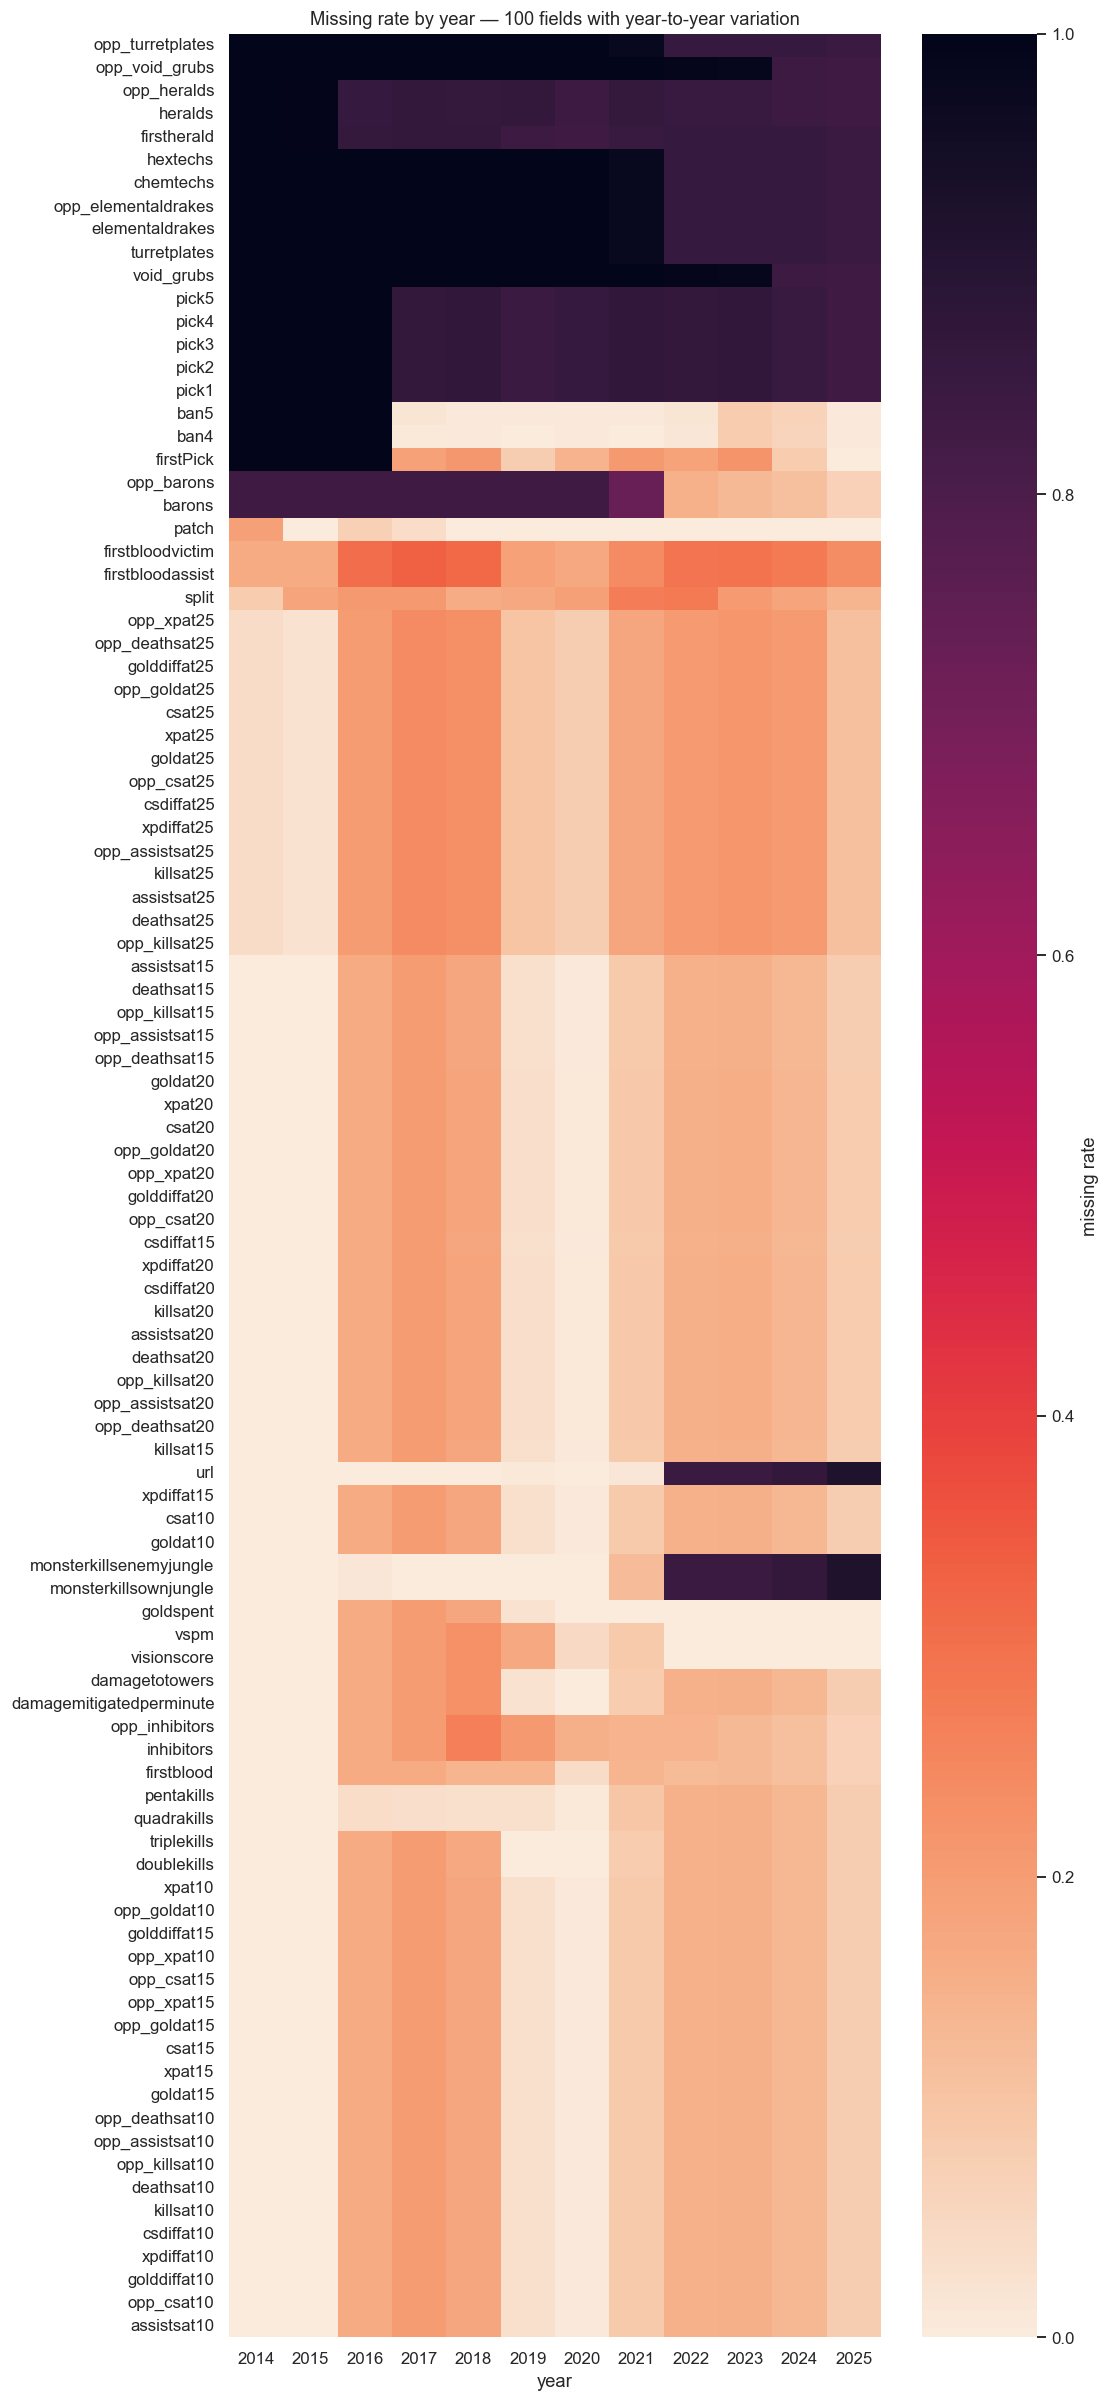

,first_usable_year
gameid,2014
opp_killsat15,2014
deathsat15,2014
assistsat15,2014
killsat15,2014
...,...
ban4,2017
ban5,2017
firstPick,2019
opp_barons,2025


In [3]:
from utils.completness import missing_rate_by_year, first_usable_year

miss = missing_rate_by_year(df=df)

varying = miss.columns[miss.std() > 0.05]
heat = miss[varying].T.sort_values(2014, ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(varying) * 0.22)))
sns.heatmap(heat, cmap="rocket_r", vmin=0, vmax=1, cbar_kws={"label": "missing rate"}, ax=ax)
ax.set_title(f"Missing rate by year — {len(varying)} fields with year-to-year variation")
plt.tight_layout()
plt.show()

first_usable_year(miss).dropna().sort_values().to_frame()

### Dataset Structure & Key Fields


### Data Completeness Across Years

Early years caveat.


### Regions Included & Sample Sizes


### Preprocessing Decisions

e.g., excluding incomplete rows, separating team rows vs. player rows.


## 3. The Evolution of the Game (Macro Trends, 2014–2025)


### Match Duration Over the Years


### Kill Pace (Kills per Minute) Over the Years


### Early-Game vs. Late-Game Resource Distribution Trends


### Key Patch Milestones

Dragon soul, objective bounties, etc.


## 4. Defining "Playstyle" — Metrics & Framework


### Aggression

KPM, first blood rate, golddiff@15.


### Early-Game Dominance

CSD@10, golddiff@10.


### Vision Control

Vision score, wards placed/killed.


### Objective Focus

Dragon rate, baron rate, herald rate.


### Game Length as a Proxy for Macro Style


## 5. Regional Style Comparison


### Head-to-Head Comparison

Major regions: LPL, LCK, LCS, LEC, others.


### Per-Metric Breakdown with Visualizations


### Statistical Testing

ANOVA / Kruskal-Wallis to confirm differences are significant.


### Summary: Regional "Fingerprints"


## 6. Patch as a Shaping Force


### Patch Changes vs. Match Tempo


### Did Patches Narrow or Widen Regional Style Gaps?


### Case Study

One or two specific patches with notable meta impact.


## 7. Conclusion


### Key Findings


### Limitations

Data gaps, roster changes, international tournaments not separated.


### Possible Extensions
